# XGBoost Forecast Training (Revenue, Demand, Sales)

This notebook trains XGBoost models for three forecast targets:
- `revenue`
- `demand`
- `sales`

It can:
1. Load daily data from your BI Platform database (or generate fallback synthetic data)
2. Train and evaluate a separate model per target
3. Save models to `backend/ml/models/saved/`
4. Run future forecasts for each metric

In [16]:
# If needed, uncomment and run once:
# %pip install xgboost pandas numpy scikit-learn sqlalchemy python-dotenv joblib matplotlib seaborn

from pathlib import Path
import json
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent
BACKEND_DIR = ROOT / "backend"
SAVE_DIR = BACKEND_DIR / "ml" / "models" / "saved"
PLOT_DIR = ROOT / "notebooks" / "outputs"
DATA_DIR = ROOT / "notebooks" / "data"
FAKE_DATA_PATH = DATA_DIR / "synthetic_daily_sales.csv"
TRANSACTION_DATA_PATH = DATA_DIR / "synthetic_sales_transactions.csv"

SAVE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Set True to always train from generated fake data
USE_FAKE_DATA = True
FAKE_DATA_DAYS = 900

print("Root:", ROOT)
print("Save dir:", SAVE_DIR)
print("Plot dir:", PLOT_DIR)
print("Daily fake data path:", FAKE_DATA_PATH)
print("Transaction fake data path:", TRANSACTION_DATA_PATH)
print("Use fake data:", USE_FAKE_DATA)

Root: d:\Project\Project VI\BI_Platform
Save dir: d:\Project\Project VI\BI_Platform\backend\ml\models\saved
Plot dir: d:\Project\Project VI\BI_Platform\notebooks\outputs
Daily fake data path: d:\Project\Project VI\BI_Platform\notebooks\data\synthetic_daily_sales.csv
Transaction fake data path: d:\Project\Project VI\BI_Platform\notebooks\data\synthetic_sales_transactions.csv
Use fake data: True


In [17]:
def generate_synthetic_transactions(n_days: int = 900) -> pd.DataFrame:
    dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=n_days, freq="D")

    rows = []
    product_ids = np.arange(1001, 1061)
    customer_ids = np.arange(50001, 50801)

    for idx, ds in enumerate(dates):
        trend = idx / max(n_days - 1, 1)
        weekly_factor = 1.0 + 0.18 * np.sin(2 * np.pi * (idx / 7.0))
        yearly_factor = 1.0 + 0.24 * np.sin(2 * np.pi * (idx / 365.0))

        # Daily transaction volume similar to POS systems
        mean_txn = 120 * (1.0 + 0.35 * trend) * weekly_factor * yearly_factor
        n_txn = max(25, int(np.random.poisson(mean_txn)))

        for _ in range(n_txn):
            product_id = int(np.random.choice(product_ids))
            customer_id = int(np.random.choice(customer_ids))

            # Product-specific base price + randomness
            product_price_anchor = 8 + (product_id % 25) * 3.5
            unit_price = max(2.5, np.random.normal(product_price_anchor, 2.2))

            quantity = int(np.random.choice([1, 2, 3, 4, 5, 6], p=[0.36, 0.28, 0.16, 0.1, 0.07, 0.03]))
            discount_pct = float(np.random.choice([0, 0.03, 0.05, 0.1, 0.15], p=[0.62, 0.14, 0.14, 0.08, 0.02]))

            gross = unit_price * quantity
            total_amount = gross * (1.0 - discount_pct)

            rows.append(
                {
                    "sale_date": ds,
                    "customer_id": customer_id,
                    "product_id": product_id,
                    "quantity": quantity,
                    "unit_price": round(unit_price, 2),
                    "discount_pct": round(discount_pct, 3),
                    "total_amount": round(total_amount, 2),
                }
            )

    tx = pd.DataFrame(rows)
    tx["sale_date"] = pd.to_datetime(tx["sale_date"])
    return tx


def aggregate_daily_from_transactions(tx: pd.DataFrame) -> pd.DataFrame:
    daily = (
        tx.assign(ds=pd.to_datetime(tx["sale_date"]).dt.normalize())
        .groupby("ds", as_index=False)
        .agg(
            revenue=("total_amount", "sum"),
            demand=("quantity", "sum"),
            sales=("total_amount", "count"),
        )
    )

    full_range = pd.date_range(daily["ds"].min(), daily["ds"].max(), freq="D")
    daily = (
        daily.set_index("ds")
        .reindex(full_range)
        .fillna(0)
        .rename_axis("ds")
        .reset_index()
    )

    for col in ["revenue", "demand", "sales"]:
        daily[col] = pd.to_numeric(daily[col], errors="coerce").fillna(0.0).astype(float)

    return daily


def save_database_like_fake_data(
    daily_csv_path: Path,
    transactions_csv_path: Path,
    n_days: int = 900,
) -> pd.DataFrame:
    tx = generate_synthetic_transactions(n_days=n_days)
    daily = aggregate_daily_from_transactions(tx)

    tx.to_csv(transactions_csv_path, index=False)
    daily.to_csv(daily_csv_path, index=False)
    return daily


def load_data_from_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    required_cols = {"ds", "revenue", "demand", "sales"}
    if not required_cols.issubset(set(df.columns)):
        missing = required_cols.difference(set(df.columns))
        raise ValueError(f"Missing required columns in CSV: {sorted(missing)}")

    df["ds"] = pd.to_datetime(df["ds"])
    df = df.sort_values("ds").reset_index(drop=True)
    full_range = pd.date_range(df["ds"].min(), df["ds"].max(), freq="D")
    df = df.set_index("ds").reindex(full_range).fillna(0).rename_axis("ds").reset_index()

    for col in ["revenue", "demand", "sales"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0).astype(float)

    return df


def load_daily_data() -> pd.DataFrame:
    if USE_FAKE_DATA:
        needs_refresh = (not FAKE_DATA_PATH.exists()) or (not TRANSACTION_DATA_PATH.exists())
        if needs_refresh:
            _ = save_database_like_fake_data(
                daily_csv_path=FAKE_DATA_PATH,
                transactions_csv_path=TRANSACTION_DATA_PATH,
                n_days=FAKE_DATA_DAYS,
            )
            print("Created database-like fake datasets:")
            print(" -", TRANSACTION_DATA_PATH)
            print(" -", FAKE_DATA_PATH)
        else:
            print("Using existing database-like fake datasets:")
            print(" -", TRANSACTION_DATA_PATH)
            print(" -", FAKE_DATA_PATH)

        df = load_data_from_csv(FAKE_DATA_PATH)
        tx_count = len(pd.read_csv(TRANSACTION_DATA_PATH))
        print(f"Loaded {len(df)} daily rows and {tx_count} transactions from fake dataset")
        return df

    # Optional database mode
    try:
        from dotenv import load_dotenv
        from sqlalchemy import create_engine, text

        env_path = BACKEND_DIR / ".env"
        if env_path.exists():
            load_dotenv(env_path)

        database_url = os.getenv("DATABASE_URL")
        if not database_url:
            raise RuntimeError("DATABASE_URL not found in environment/.env")

        if database_url.startswith("postgresql+asyncpg://"):
            database_url = database_url.replace("postgresql+asyncpg://", "postgresql+psycopg2://", 1)

        engine = create_engine(database_url)

        query = text("""
            SELECT
                DATE(sale_date) AS ds,
                COALESCE(SUM(total_amount), 0) AS revenue,
                COALESCE(SUM(quantity), 0) AS demand,
                COALESCE(COUNT(*), 0) AS sales
            FROM sales
            GROUP BY DATE(sale_date)
            ORDER BY ds ASC
        """)

        df = pd.read_sql(query, engine)
        if df.empty:
            raise RuntimeError("No sales data found")

        df["ds"] = pd.to_datetime(df["ds"])
        full_range = pd.date_range(df["ds"].min(), df["ds"].max(), freq="D")
        df = df.set_index("ds").reindex(full_range).fillna(0).rename_axis("ds").reset_index()

        for col in ["revenue", "demand", "sales"]:
            df[col] = df[col].astype(float)

        print(f"Loaded {len(df)} daily rows from database")
        return df

    except Exception as exc:
        print("Database load failed. Falling back to database-like fake datasets.")
        print("Reason:", exc)
        _ = save_database_like_fake_data(
            daily_csv_path=FAKE_DATA_PATH,
            transactions_csv_path=TRANSACTION_DATA_PATH,
            n_days=FAKE_DATA_DAYS,
        )
        print("Created fallback fake datasets:")
        print(" -", TRANSACTION_DATA_PATH)
        print(" -", FAKE_DATA_PATH)
        return load_data_from_csv(FAKE_DATA_PATH)


daily_df = load_daily_data()
daily_df.head()

Created database-like fake datasets:
 - d:\Project\Project VI\BI_Platform\notebooks\data\synthetic_sales_transactions.csv
 - d:\Project\Project VI\BI_Platform\notebooks\data\synthetic_daily_sales.csv
Loaded 900 daily rows and 130852 transactions from fake dataset


,ds,revenue,demand,sales
0,2023-10-03,12947.42,270.0,116.0
1,2023-10-04,14692.43,310.0,135.0
2,2023-10-05,13389.05,283.0,121.0
3,2023-10-06,17785.16,381.0,152.0
4,2023-10-07,12358.10,273.0,118.0


In [18]:
FEATURES = [
    "dow", "month", "quarter", "doy", "year",
    "lag_1", "lag_7", "lag_14", "lag_30",
    "roll_7", "roll_30",
]


def build_feature_frame(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    d = df[["ds", target_col]].copy()
    d = d.rename(columns={target_col: "y"})

    d["dow"] = d["ds"].dt.dayofweek
    d["month"] = d["ds"].dt.month
    d["quarter"] = d["ds"].dt.quarter
    d["doy"] = d["ds"].dt.dayofyear
    d["year"] = d["ds"].dt.year

    for lag in [1, 7, 14, 30]:
        d[f"lag_{lag}"] = d["y"].shift(lag)

    d["roll_7"] = d["y"].shift(1).rolling(7).mean()
    d["roll_30"] = d["y"].shift(1).rolling(30).mean()

    d = d.dropna().reset_index(drop=True)
    return d


def compute_success_percent(y_true: pd.Series, y_pred: np.ndarray) -> float:
    # Accuracy proxy for regression: 100 - MAPE (%)
    y_true_arr = np.array(y_true, dtype=float)
    y_pred_arr = np.array(y_pred, dtype=float)
    denom = np.where(np.abs(y_true_arr) < 1e-8, 1.0, np.abs(y_true_arr))
    mape = np.mean(np.abs((y_true_arr - y_pred_arr) / denom)) * 100.0
    return float(max(0.0, 100.0 - mape))


def train_one_metric(df: pd.DataFrame, target_col: str) -> tuple[xgb.XGBRegressor, dict]:
    feat = build_feature_frame(df, target_col)

    # Explicit 80/20 split
    split_idx = int(len(feat) * 0.8)
    train = feat.iloc[:split_idx].copy()
    val = feat.iloc[split_idx:].copy()

    model = xgb.XGBRegressor(
        n_estimators=350,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric=["rmse", "mae"],
    )

    model.fit(
        train[FEATURES],
        train["y"],
        eval_set=[(train[FEATURES], train["y"]), (val[FEATURES], val["y"])],
        verbose=False,
    )

    train_pred = model.predict(train[FEATURES])
    val_pred = model.predict(val[FEATURES])

    train_rmse = float(np.sqrt(mean_squared_error(train["y"], train_pred)))
    val_rmse = float(np.sqrt(mean_squared_error(val["y"], val_pred)))
    train_mae = float(mean_absolute_error(train["y"], train_pred))
    val_mae = float(mean_absolute_error(val["y"], val_pred))
    val_r2 = float(r2_score(val["y"], val_pred))

    train_success = compute_success_percent(train["y"], train_pred)
    val_success = compute_success_percent(val["y"], val_pred)

    evals = model.evals_result()
    train_loss_curve = evals.get("validation_0", {}).get("rmse", [])
    val_loss_curve = evals.get("validation_1", {}).get("rmse", [])

    metrics = {
        "train_rows": int(len(train)),
        "val_rows": int(len(val)),
        "train_rmse": round(train_rmse, 3),
        "val_rmse": round(val_rmse, 3),
        "train_mae": round(train_mae, 3),
        "val_mae": round(val_mae, 3),
        "val_r2": round(val_r2, 4),
        "train_accuracy_pct": round(train_success, 2),
        "val_accuracy_pct": round(val_success, 2),
        "train_loss_last": round(float(train_loss_curve[-1]) if train_loss_curve else np.nan, 4),
        "val_loss_last": round(float(val_loss_curve[-1]) if val_loss_curve else np.nan, 4),
        "train_loss_curve": [float(x) for x in train_loss_curve],
        "val_loss_curve": [float(x) for x in val_loss_curve],
        "val_actual": [float(x) for x in val["y"].values],
        "val_pred": [float(x) for x in val_pred],
    }

    return model, metrics

In [19]:
targets = ["revenue", "demand", "sales"]
trained_models: dict[str, xgb.XGBRegressor] = {}
metrics_report: dict[str, dict] = {}

for target in targets:
    model, metrics = train_one_metric(daily_df, target)
    trained_models[target] = model
    metrics_report[target] = metrics

# Compact evaluation matrix
summary_cols = [
    "train_rows", "val_rows",
    "train_accuracy_pct", "val_accuracy_pct",
    "train_loss_last", "val_loss_last",
    "train_rmse", "val_rmse", "train_mae", "val_mae", "val_r2",
]

metrics_df = pd.DataFrame(metrics_report).T[summary_cols]
print("Model training + validation performance (80/20 split)")
display(metrics_df)

Model training + validation performance (80/20 split)


,train_rows,val_rows,train_accuracy_pct,val_accuracy_pct,train_loss_last,val_loss_last,train_rmse,val_rmse,train_mae,val_mae,val_r2
revenue,696,174,97.75,89.86,390.4367,2473.8004,390.437,2473.8,301.123,1992.945,0.4653
demand,696,174,98.1,89.82,7.4845,60.3521,7.484,60.352,5.671,45.978,0.3369
sales,696,174,98.32,89.91,2.8504,24.3658,2.85,24.366,2.172,19.356,0.351


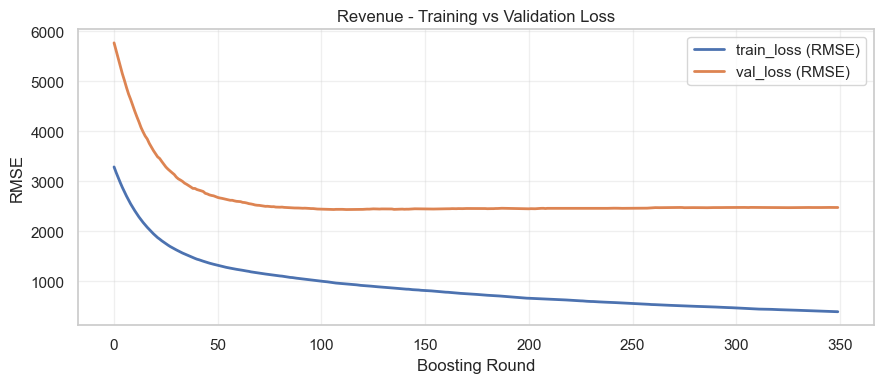

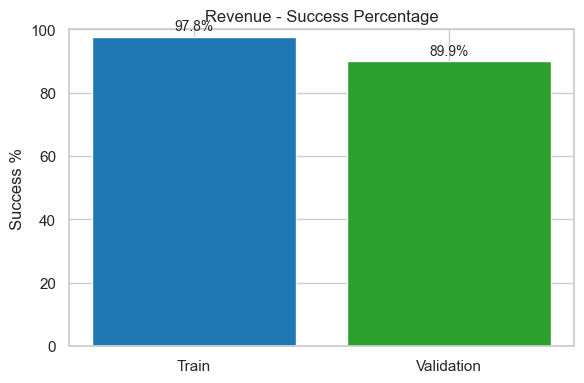

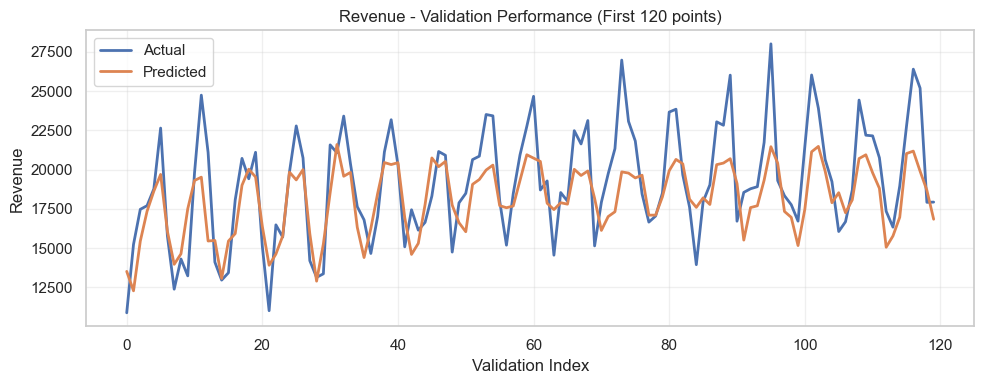

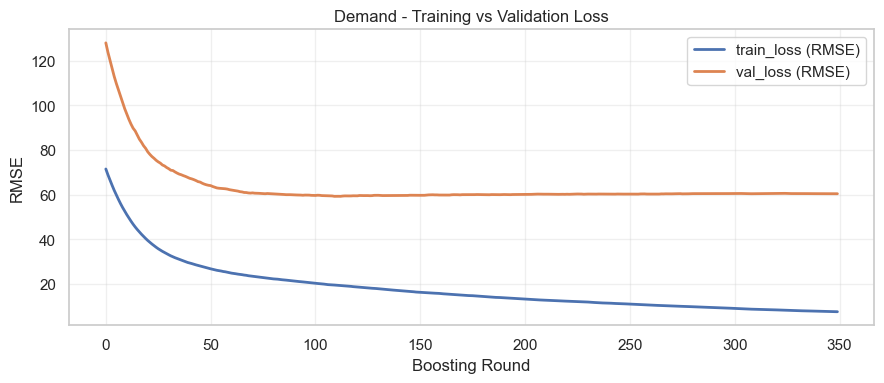

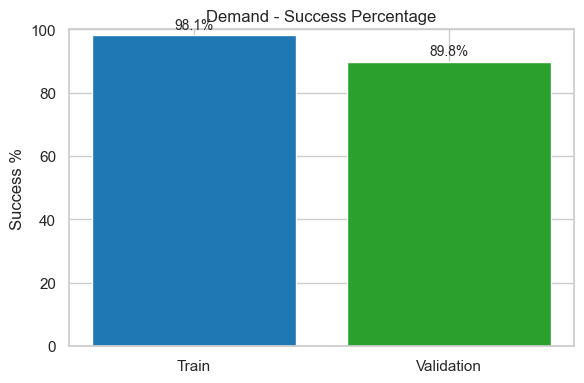

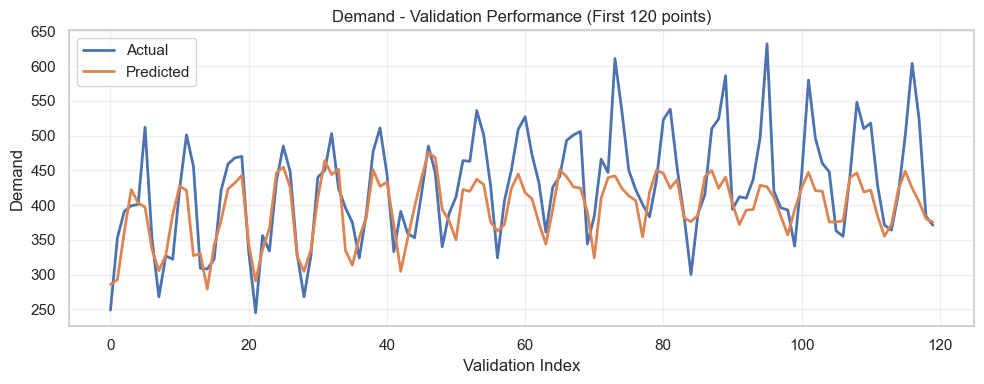

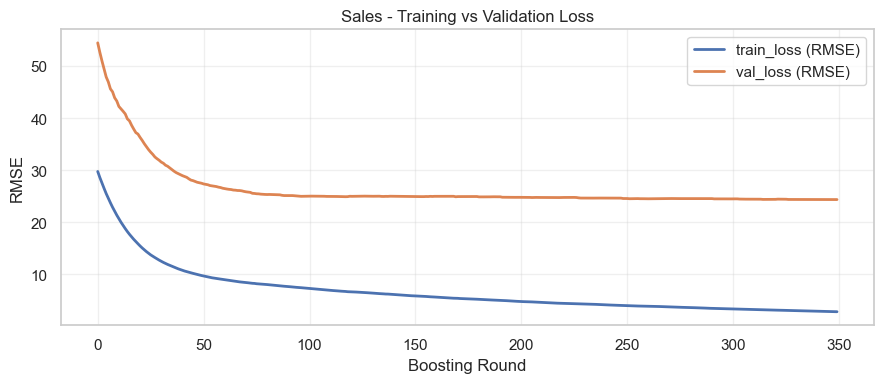

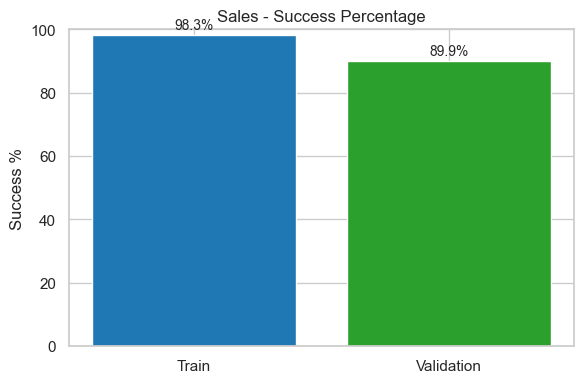

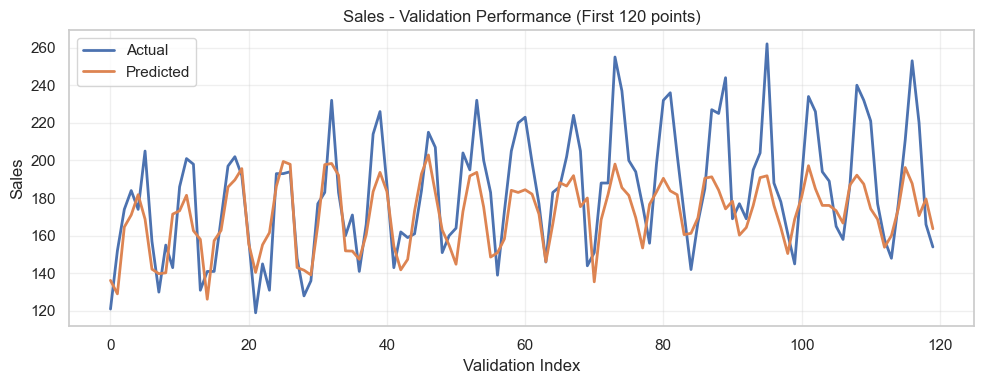

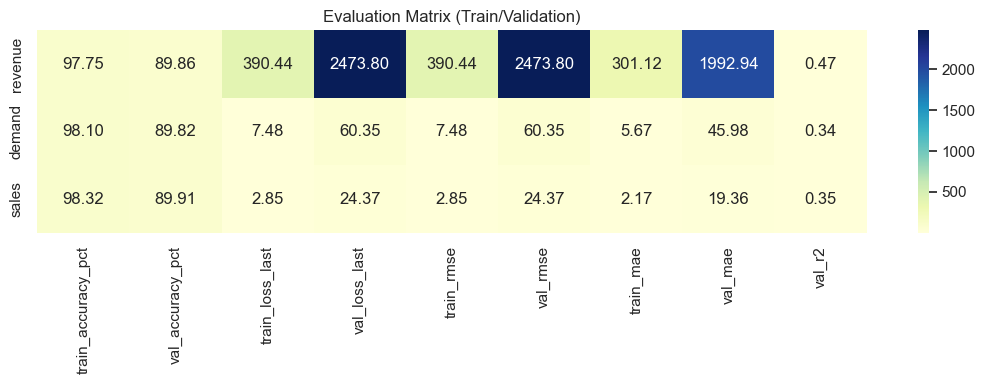

Saved visualization images:
 - revenue_loss_curve.png
 - revenue_success_percent.png
 - revenue_validation_performance.png
 - demand_loss_curve.png
 - demand_success_percent.png
 - demand_validation_performance.png
 - sales_loss_curve.png
 - sales_success_percent.png
 - sales_validation_performance.png
 - evaluation_matrix_heatmap.png


In [20]:
# Visual outputs: loss curves, success rate, evaluation matrix, and prediction performance
plot_paths = []

for metric in targets:
    report = metrics_report[metric]

    # 1) Training vs validation loss curve
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(report["train_loss_curve"], label="train_loss (RMSE)", linewidth=2)
    ax.plot(report["val_loss_curve"], label="val_loss (RMSE)", linewidth=2)
    ax.set_title(f"{metric.title()} - Training vs Validation Loss")
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel("RMSE")
    ax.legend()
    ax.grid(alpha=0.3)
    loss_path = PLOT_DIR / f"{metric}_loss_curve.png"
    fig.tight_layout()
    fig.savefig(loss_path, dpi=140)
    plt.show()
    plt.close(fig)
    plot_paths.append(loss_path)

    # 2) Success percent (accuracy proxy) chart
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(
        ["Train", "Validation"],
        [report["train_accuracy_pct"], report["val_accuracy_pct"]],
        color=["#1f77b4", "#2ca02c"],
    )
    ax.set_ylim(0, 100)
    ax.set_title(f"{metric.title()} - Success Percentage")
    ax.set_ylabel("Success %")
    for b in bars:
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 1,
            f"{b.get_height():.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
        )
    success_path = PLOT_DIR / f"{metric}_success_percent.png"
    fig.tight_layout()
    fig.savefig(success_path, dpi=140)
    plt.show()
    plt.close(fig)
    plot_paths.append(success_path)

    # 3) Validation actual vs predicted performance
    val_comp = pd.DataFrame({
        "actual": report["val_actual"],
        "predicted": report["val_pred"],
    }).head(120)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(val_comp["actual"].values, label="Actual", linewidth=2)
    ax.plot(val_comp["predicted"].values, label="Predicted", linewidth=2)
    ax.set_title(f"{metric.title()} - Validation Performance (First 120 points)")
    ax.set_xlabel("Validation Index")
    ax.set_ylabel(metric.title())
    ax.legend()
    ax.grid(alpha=0.3)
    perf_path = PLOT_DIR / f"{metric}_validation_performance.png"
    fig.tight_layout()
    fig.savefig(perf_path, dpi=140)
    plt.show()
    plt.close(fig)
    plot_paths.append(perf_path)

# 4) Evaluation matrix heatmap
eval_matrix = metrics_df[[
    "train_accuracy_pct", "val_accuracy_pct",
    "train_loss_last", "val_loss_last",
    "train_rmse", "val_rmse", "train_mae", "val_mae", "val_r2",
]].apply(pd.to_numeric, errors="coerce").fillna(0.0)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(eval_matrix, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, ax=ax)
ax.set_title("Evaluation Matrix (Train/Validation)")
matrix_path = PLOT_DIR / "evaluation_matrix_heatmap.png"
fig.tight_layout()
fig.savefig(matrix_path, dpi=140)
plt.show()
plt.close(fig)
plot_paths.append(matrix_path)

print("Saved visualization images:")
for p in plot_paths:
    print(" -", p.name)

In [21]:
for target, model in trained_models.items():
    out_path = SAVE_DIR / f"xgboost_{target}.pkl"
    joblib.dump(model, out_path)

metrics_path = SAVE_DIR / "xgboost_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_report, f, indent=2)

print("Saved models and metrics:")
for p in sorted(SAVE_DIR.glob("xgboost_*")):
    print(" -", p.name)

Saved models and metrics:
 - xgboost_demand.pkl
 - xgboost_metrics.json
 - xgboost_revenue.pkl
 - xgboost_sales.pkl


In [15]:
def forecast_metric(df: pd.DataFrame, metric: str, periods: int = 30) -> pd.DataFrame:
    model_path = SAVE_DIR / f"xgboost_{metric}.pkl"
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    model: xgb.XGBRegressor = joblib.load(model_path)

    base = df[["ds", metric]].copy().rename(columns={metric: "y"})
    last_vals = list(base["y"].astype(float).values[-30:])

    start_date = base["ds"].max() + pd.Timedelta(days=1)
    future_dates = pd.date_range(start=start_date, periods=periods, freq="D")

    rows = []
    for d in future_dates:
        feat = {
            "dow": d.dayofweek,
            "month": d.month,
            "quarter": d.quarter,
            "doy": d.dayofyear,
            "year": d.year,
            "lag_1": last_vals[-1],
            "lag_7": last_vals[-7],
            "lag_14": last_vals[-14],
            "lag_30": last_vals[-30],
            "roll_7": float(np.mean(last_vals[-7:])),
            "roll_30": float(np.mean(last_vals[-30:])),
        }

        pred = float(model.predict(pd.DataFrame([feat]))[0])
        pred = max(pred, 0.0)
        last_vals.append(pred)

        spread = float(np.std(last_vals[-30:]) * 0.15)
        rows.append({
            "date": d.strftime("%Y-%m-%d"),
            "predicted": round(pred, 2),
            "lower": round(max(pred - spread, 0.0), 2),
            "upper": round(pred + spread, 2),
        })

    return pd.DataFrame(rows)


for metric in ["revenue", "demand", "sales"]:
    print("\n=== Forecast:", metric, "===")
    display(forecast_metric(daily_df, metric, periods=14).head(10))


=== Forecast: revenue ===


,date,predicted,lower,upper
0,2026-03-21,53038.27,52717.67,53358.88
1,2026-03-22,53222.98,52897.48,53548.47
2,2026-03-23,55676.22,55363.62,55988.83
3,2026-03-24,57252.84,56945.99,57559.69
4,2026-03-25,57587.84,57280.77,57894.90
5,2026-03-26,57198.91,56889.26,57508.56
6,2026-03-27,55035.63,54726.28,55344.98
7,2026-03-28,53014.48,52696.74,53332.23
8,2026-03-29,53407.73,53091.96,53723.49
9,2026-03-30,55155.91,54858.54,55453.27



=== Forecast: demand ===


,date,predicted,lower,upper
0,2026-03-21,267.12,265.76,268.49
1,2026-03-22,266.52,265.16,267.88
2,2026-03-23,276.17,274.84,277.50
3,2026-03-24,278.24,276.94,279.54
4,2026-03-25,283.76,282.45,285.07
5,2026-03-26,279.21,277.88,280.54
6,2026-03-27,273.81,272.48,275.14
7,2026-03-28,270.80,269.49,272.10
8,2026-03-29,272.46,271.22,273.70
9,2026-03-30,274.99,273.89,276.10



=== Forecast: sales ===


,date,predicted,lower,upper
0,2026-03-21,162.12,160.03,164.21
1,2026-03-22,162.51,160.41,164.61
2,2026-03-23,181.63,179.60,183.66
3,2026-03-24,193.60,191.57,195.64
4,2026-03-25,196.72,194.63,198.82
5,2026-03-26,184.91,182.85,186.97
6,2026-03-27,170.44,168.49,172.39
7,2026-03-28,161.36,159.37,163.35
8,2026-03-29,161.91,159.88,163.94
9,2026-03-30,180.28,178.31,182.26
